# EDA of Dataloader with Multicoil Data


## Libraries and Modules


In [5]:
from torch.utils.data import Dataset
import torch
import numpy as np
import sys
import importlib
import fastmri
from numpy import random
import matplotlib.pyplot as plt
from load_mri_data import show_coils, show_multicoil_K_I, convert_K_to_I, convert_I_to_K, rss_combine
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask
import time
import itertools
from torch.utils.data import DataLoader
import glob
import h5py

In [ ]:
is_notebook = True # IPYNB does not reload the previously imported packages and hence we need to reload to reflect changes without losing the variables
def reload_modules(): 
    if is_notebook:
        importlib.reload(sys.modules['load_mri_data'])  # Reloading the file to reflect changes
        from load_mri_data import show_coils, show_multicoil_K_I, convert_K_to_I, convert_I_to_K, rss_combine
        print("Reloaded Modules")
reload_modules()    

Reloaded Modules


#### Custom Dataloader

Considering uniform coil-length-width data. In general, we need to unify all the data points (but not doing it here).

In [ ]:
class Custom_FMRI_DataLoader_nil(Dataset):
    def __init__(self, data_paths,\
                   mask_func=EquiSpacedMaskFunc(center_fractions=[0.08],accelerations=[20]),\
                    transform=None,\
                    input_req=[1, 1, 1, 1, 1],\
                    output_req=[1, 1, 1, 1],
                ):  
        
        if len(input_req)!=5:
            print("Wrong ip parameters, Assigning Brute force.!!!")
            input_req=[1, 1, 1, 1, 1] #[k_space_mc, I space mc, rss combine, fft_rss_combine, mask]
        
        if len(output_req)!=4:
            print("Wrong output parameters, Assigning Brute force.!!!")
            output_req=[1, 1, 1, 1] #[k_space_mc_ua, I space mc_ua, rss combine_ua, fft_rss_combine_ua]

        # self.dataset = np.load(data_path, mmap_mode='r')
        self.paths = data_paths
        self.length = len(self.paths)
        self.mask_func = mask_func
        self.transform = transform
        

        #setting 5 i/p Flags
        self.K = input_req[0]
        self.I = input_req[1]
        self.rss_combine = input_req[2]
        self.rss_fft=input_req[3]
        self.mask=input_req[4]
        
        #setting 4 o/p Flags
        self.K_full = output_req[0]
        self.I_full = output_req[1]
        self.rss_combine_full = output_req[2]
        self.rss_fft_full= output_req[3]

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        # Dictionary to store the return values
        dd={}
        #Loading Data
        self.dataset = np.load(self.paths[index], mmap_mode ='r')
        slice_kspace = self.dataset

        # To save RAM space (by loading only what is required)
        if self.K_full ==1:
            dd["full_k_space"] = slice_kspace  
                
        if self.I_full==1:
            slice_ispace = convert_K_to_I(slice_kspace)
            dd["full_i_space"]=slice_ispace
            
            
        if self.rss_combine_full==1:
            if self.I_full !=1:
                slice_ispace = convert_K_to_I(slice_kspace)
            rss_combined = rss_combine(slice_ispace)
            dd["full_rss_combined"]= rss_combined
           
        if self.rss_fft_full==1:
            if self.rss_combine_full!=1:
                if self.I_full !=1:
                    slice_ispace = convert_K_to_I(slice_kspace)
                rss_combined = rss_combine(slice_ispace)

            # rss_combined_array = np.array(rss_combined, dtype=np.float32)

            # Apply FFT with 'ortho' normalization
            # rss_combined_fft_np = np.fft.fft2(rss_combined_array, norm='ortho')
            # rss_combined_fft_np_shifted = np.fft.fftshift(rss_combined_fft_np)
            rss_combined_tensor = torch.tensor(rss_combined, dtype=torch.float32)
            rss_combined_fft = torch.fft.fft2(rss_combined_tensor, norm='ortho')
            rss_combined_fft = torch.fft.fftshift(rss_combined_fft)

            dd["full_rss_fft"]=rss_combined_fft

        ####################################################
        if self.K ==1:
            masked_kspace, mask, _ = apply_mask(torch.tensor(slice_kspace), self.mask_func)
            dd["masked_k_space"]=masked_kspace  
                
        if self.I==1:
            if self.K !=1: #If self.K was 1 then we already have the masked K space
                masked_kspace, mask, _ = apply_mask(torch.tensor(slice_kspace), self.mask_func)
            masked_ispace = convert_K_to_I(masked_kspace)
            dd["masked_i_space"] = masked_ispace

        if self.rss_combine==1:
            if self.I!=1:
                if self.K !=1:
                    masked_kspace, mask, _ = apply_mask(torch.tensor(slice_kspace), self.mask_func)
                masked_ispace = convert_K_to_I(masked_kspace)
            masked_rss_combined = rss_combine(masked_ispace)
            dd["masked_rss_combined"]= masked_rss_combined
           
        if self.rss_fft==1:
            if self.rss_combine!=1:
                if self.I!=1:
                    if self.K !=1:
                        masked_kspace, mask, _ = apply_mask(torch.tensor(slice_kspace), self.mask_func)
                    masked_ispace = convert_K_to_I(masked_kspace)
                masked_rss_combined = rss_combine(masked_ispace)
            
            masked_rss_combined_tensor = torch.tensor(masked_rss_combined, dtype=torch.float32)
            masked_rss_combined_fft = torch.fft.fft2(masked_rss_combined_tensor, norm='ortho')
            masked_rss_combined_fft= torch.fft.fftshift(masked_rss_combined_fft)
            
            dd["masked_rss_combined_fft"]= masked_rss_combined_fft

        if self.mask==1:
            maskfull, _, _ = apply_mask(torch.ones_like(torch.tensor(slice_kspace)), self.mask_func)
            dd["mask"] = maskfull
        
        return dd

In [ ]:
import time
import torch
from torch.utils.data import DataLoader
import os

# 1. Setup your file paths (assuming you have a list of .npy paths)
output_path = "/home/biswamitra/health/knee_data/train/deconstructed_train"
paths = [os.path.join(output_path, f) for f in os.listdir(output_path) if f.endswith('.npy')]

# 2. Initialize Dataset and DataLoader
dataset = Custom_FMRI_DataLoader_nil(data_paths=paths) 

# Increase num_workers to utilize CPU cores for faster loading
loader = DataLoader(
    dataset, 
    batch_size=16, 
    shuffle=False, 
    num_workers=4,  # Adjust based on your CPU cores
    pin_memory=True # Speeds up transfer to GPU
)

def benchmark_epoch(dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting benchmark on {device}...")
    
    start_time = time.perf_counter()
    num_items = 0
    
    for i, batch in enumerate(dataloader):
        # Optional: Move a small tensor to GPU to simulate real training overhead
        # x = batch["masked_k_space"].to(device) 
        
        num_items += len(next(iter(batch.values())))
        
        if i % 10 == 0:
            elapsed = time.perf_counter() - start_time
            print(f"Batch {i} | Speed: {num_items / elapsed:.2f} items/sec", end='\r')

    end_time = time.perf_counter()
    total_time = end_time - start_time
    
    print(f"\n" + "-"*30)
    print(f"Benchmark Complete")
    print(f"Total Items: {num_items}")
    print(f"Total Time:  {total_time:.2f} seconds")
    print(f"Avg Throughput: {num_items / total_time:.2f} items/sec")
    print("-"*30)

if __name__ == "__main__":
    benchmark_epoch(loader)

In [ ]:
!pip install fastmri

Loaded Shape: (15, 640, 372)
Data Type: complex64
ifft2c result shape :  torch.Size([15, 640, 372, 2])


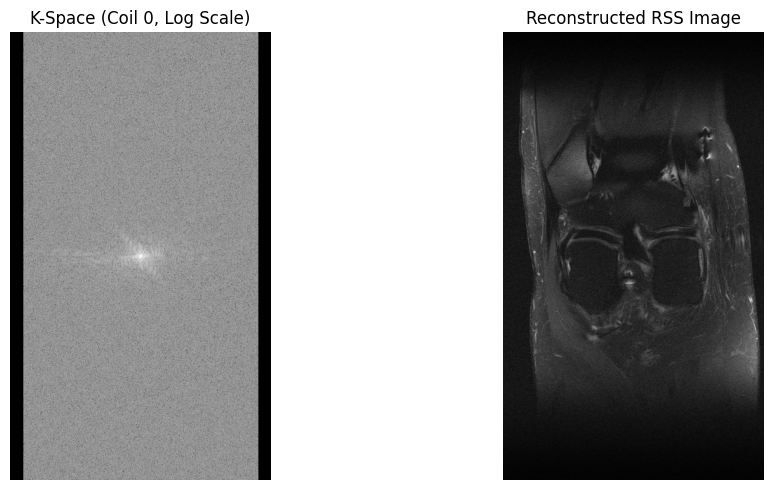

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import fastmri
from fastmri.data import transforms as T

# Path to one of your deconstructed slices
file_path = "/home/biswamitra/health/knee_data/train/deconstructed_train/file1000001_025.npy"

# 1. Load the data
# Expected shape: (coils, x, y) as complex numbers
slice_data = np.load(file_path)
print(f"Loaded Shape: {slice_data.shape}")
print(f"Data Type: {slice_data.dtype}")

# 2. Convert to Image Space
# fastmri.ifft2c expects a tensor with a final (real, imag) dimension
slice_tensor = T.to_tensor(slice_data) 
image_space = fastmri.ifft2c(slice_tensor)
print("ifft2c result shape : " ,image_space.shape)

# 3. RSS Combine
# Calculate magnitude, then Root Sum of Squares across the coil dimension (dim 0)
magnitude = torch.sqrt(torch.sum(image_space**2, dim=-1)) # (coils, x, y)
rss_image = torch.sqrt(torch.sum(magnitude**2, dim=0))   # (x, y)

# 4. Visualization
plt.figure(figsize=(12, 5))

# Plot Log-Kspace (taking the first coil for visualization)
plt.subplot(1, 2, 1)
k_sample = np.abs(slice_data[0])
plt.imshow(np.log(k_sample + 1e-9), cmap='gray')
plt.title("K-Space (Coil 0, Log Scale)")
plt.axis('off')

# Plot RSS Reconstructed Image
plt.subplot(1, 2, 2)
plt.imshow(rss_image.numpy(), cmap='gray')
plt.title("Reconstructed RSS Image")
plt.axis('off')

plt.tight_layout()
plt.show()

Total slices in volume: 35
Using slice 17
k_space_tensor:  torch.Size([15, 640, 368, 2])
ifft_data:  torch.Size([15, 640, 368, 2])
abs_data:  torch.Size([15, 640, 368])
rss_image_data:  torch.Size([640, 368])
RSS min: 0.0000
RSS max: 0.0001


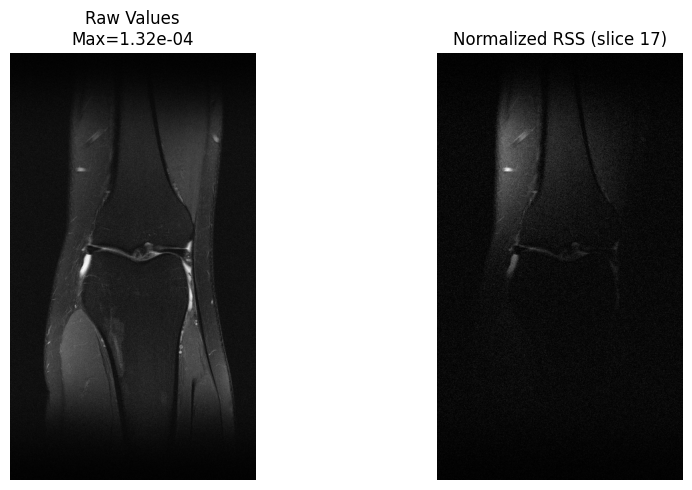

In [13]:
#load data
file_path = "/home/biswamitra/health/knee_data/val/multicoil_val/file1000000.h5"
with h5py.File(file_path,'r') as hf:
    # Check how many slices
    print(f"Total slices in volume: {hf['kspace'].shape[0]}")
    # Use MIDDLE slice, not first (first is often empty/noise)
    middle_slice = hf['kspace'].shape[0] // 2
    print(f"Using slice {middle_slice}")
    k_space_data = hf['kspace'][middle_slice]
k_space_tensor = T.to_tensor(k_space_data)
print("k_space_tensor: ",k_space_tensor.shape)
ifft_data = fastmri.ifft2c(k_space_tensor)
print("ifft_data: ",ifft_data.shape)
abs_data = fastmri.complex_abs(ifft_data)
print("abs_data: ",abs_data.shape)

#do simple rss
rss_image_data = fastmri.rss(abs_data,dim=0)
print("rss_image_data: ",rss_image_data.shape)

# Check value range
print(f"RSS min: {rss_image_data.min():.4f}")
print(f"RSS max: {rss_image_data.max():.4f}")

# Visualize with proper normalization  
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Without normalization (will look bad if values are small)
axes[0].imshow(rss_image_data.numpy(), cmap='gray')
axes[0].set_title(f'Raw Values\nMax={rss_image_data.max():.2e}')
axes[0].axis('off')

# # With percentile normalization (CORRECT way)
# rss_norm = normalize_for_display(rss_image_data, method='percentile', p_low=1, p_high=99)
axes[1].imshow(abs_data[0], cmap='gray')
axes[1].set_title(f'Normalized RSS (slice {middle_slice})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Original k-space : torch.Size([15, 640, 368, 2])
Image space       : torch.Size([15, 640, 368, 2])
After crop        : torch.Size([15, 320, 320, 2])
New k-space       : torch.Size([15, 320, 320, 2])


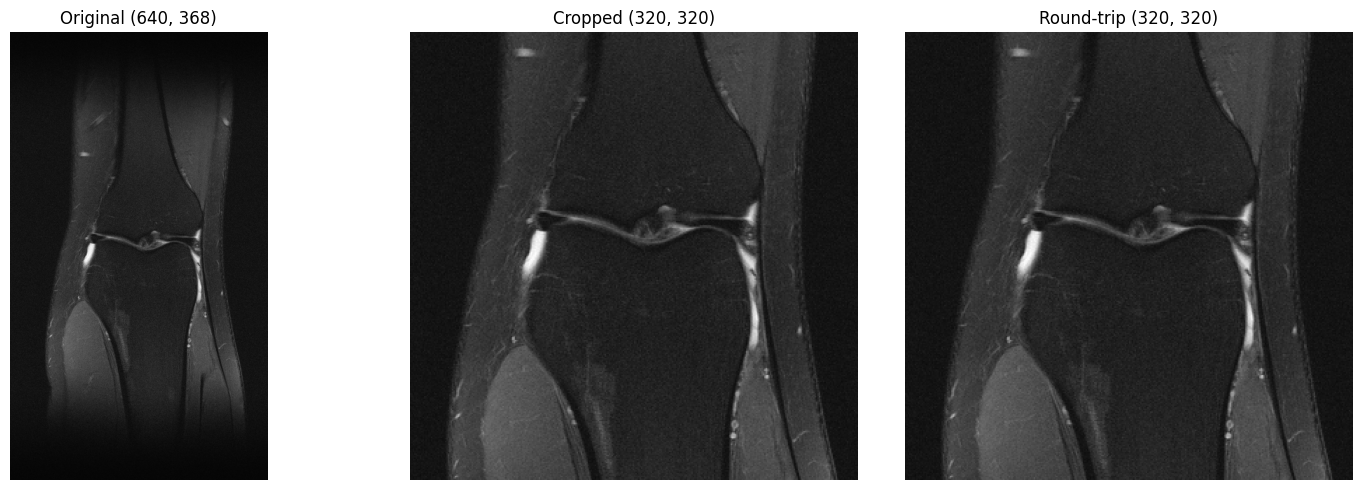

In [16]:
import h5py
import torch
import fastmri
from fastmri.data import transforms as T
import matplotlib.pyplot as plt


# ──────────────────────────────────────────────
# 1. Load k-space
# ──────────────────────────────────────────────
file_path = "/home/biswamitra/health/knee_data/val/multicoil_val/file1000000.h5"

with h5py.File(file_path, "r") as hf:
    middle_slice = hf["kspace"].shape[0] // 2
    k_space_data = hf["kspace"][middle_slice]

k_space_tensor = T.to_tensor(k_space_data)            # (15, 640, 368, 2)
print("Original k-space :", k_space_tensor.shape)


# ──────────────────────────────────────────────
# 2. K-space → Image space (per coil, complex)
# ──────────────────────────────────────────────
image_space = fastmri.ifft2c(k_space_tensor)           # (15, 640, 368, 2)
print("Image space       :", image_space.shape)


# ──────────────────────────────────────────────
# 3. Center crop using fastMRI's built-in function
# ──────────────────────────────────────────────
TARGET = (320, 320)

# This is fastMRI's own function for complex data (..., H, W, 2)
image_cropped = T.complex_center_crop(image_space, TARGET)
print("After crop        :", image_cropped.shape)      # (15, 320, 320, 2)


# ──────────────────────────────────────────────
# 4. Image space → K-space (back again)
# ──────────────────────────────────────────────
k_space_new = fastmri.fft2c(image_cropped)             # (15, 320, 320, 2)
print("New k-space       :", k_space_new.shape)


# ──────────────────────────────────────────────
# 5. Verify: reconstruct & visualize
# ──────────────────────────────────────────────
rss_original  = fastmri.rss(fastmri.complex_abs(image_space), dim=0)
rss_cropped   = fastmri.rss(fastmri.complex_abs(image_cropped), dim=0)

image_roundtrip = fastmri.ifft2c(k_space_new)
rss_roundtrip   = fastmri.rss(fastmri.complex_abs(image_roundtrip), dim=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(
    axes,
    [rss_original, rss_cropped, rss_roundtrip],
    [f"Original {tuple(rss_original.shape)}",
     f"Cropped {tuple(rss_cropped.shape)}",
     f"Round-trip {tuple(rss_roundtrip.shape)}"],
):
    ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=img.max())
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


Original k-space : torch.Size([15, 640, 368, 2])
Image space       : torch.Size([15, 640, 368, 2])
After crop/pad    : torch.Size([15, 320, 400, 2])
New k-space       : torch.Size([15, 320, 400, 2])
difference:  tensor(-1.8946e-07)


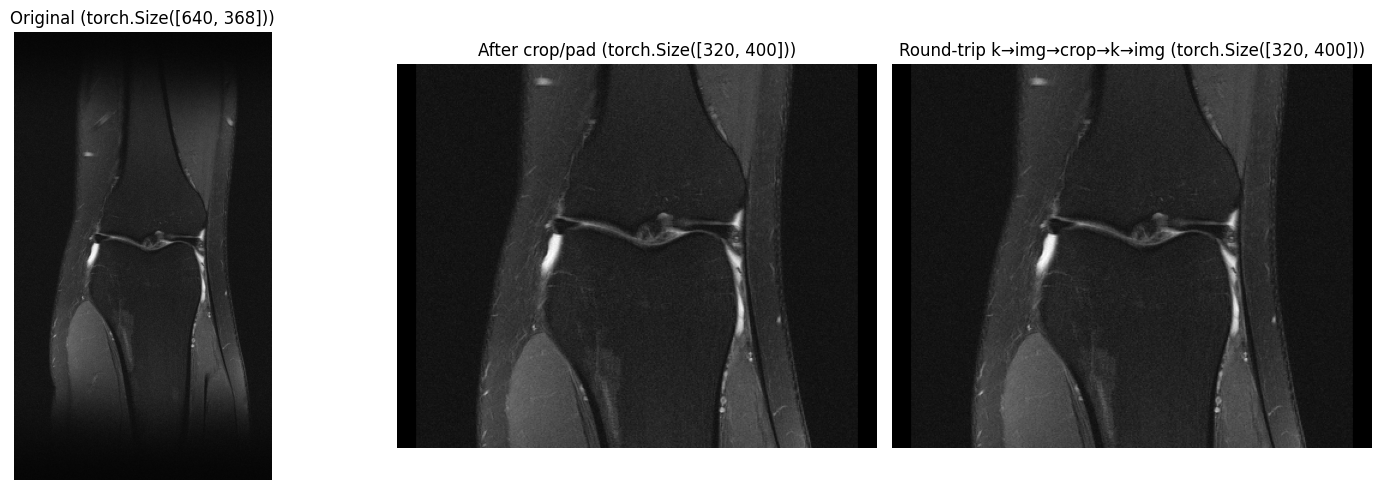

In [10]:
import h5py
import torch
import torch.nn.functional as F
import fastmri
from fastmri.data import transforms as T
import matplotlib.pyplot as plt
import numpy as np


# ──────────────────────────────────────────────
# 1. Core utility: crop OR pad complex tensors
# ──────────────────────────────────────────────
def complex_center_crop_or_pad(data, target_shape):
    """
    Center-crop or zero-pad complex data to target spatial size.

    Args:
        data:         (..., H, W, 2)   — last dim is [real, imag]
        target_shape: (target_H, target_W)

    Returns:
        (..., target_H, target_W, 2)
    """
    h, w = data.shape[-3], data.shape[-2]
    th, tw = target_shape

    # ---- Handle Height (dim -3) ----
    if h > th:                          # crop
        start = (h - th) // 2
        data = data[..., start : start + th, :, :]
    elif h < th:                        # pad
        pad_top = (th - h) // 2
        pad_bot = th - h - pad_top
        # F.pad order: (last_L, last_R, second_last_L, second_last_R, third_last_L, third_last_R)
        data = F.pad(data, (0, 0, 0, 0, pad_top, pad_bot))

    # ---- Handle Width (dim -2) ----
    w = data.shape[-2]                  # refresh after height change
    if w > tw:                          # crop
        start = (w - tw) // 2
        data = data[..., start : start + tw, :]
    elif w < tw:                        # pad
        pad_left  = (tw - w) // 2
        pad_right = tw - w - pad_left
        data = F.pad(data, (0, 0, pad_left, pad_right))

    return data


# ──────────────────────────────────────────────
# 2. Load k-space
# ──────────────────────────────────────────────
file_path = "/home/biswamitra/health/knee_data/val/multicoil_val/file1000000.h5"

with h5py.File(file_path, "r") as hf:
    middle_slice = hf["kspace"].shape[0] // 2
    k_space_data = hf["kspace"][middle_slice]       # numpy complex64

k_space_tensor = T.to_tensor(k_space_data)          # (15, 640, 368, 2)
print("Original k-space :", k_space_tensor.shape)


# ──────────────────────────────────────────────
# 3. K-space  →  Image space  (per coil, complex)
# ──────────────────────────────────────────────
image_space = fastmri.ifft2c(k_space_tensor)         # (15, 640, 368, 2)
print("Image space       :", image_space.shape)


# ──────────────────────────────────────────────
# 4. Center crop / pad in image space
# ──────────────────────────────────────────────
TARGET = (320, 400)   # change to whatever you need

image_cropped = complex_center_crop_or_pad(image_space, TARGET)
print("After crop/pad    :", image_cropped.shape)    # (15, 320, 320, 2)


# ──────────────────────────────────────────────
# 5. Image space  →  K-space  (back again)
# ──────────────────────────────────────────────
k_space_new = fastmri.fft2c(image_cropped)           # (15, 320, 320, 2)
print("New k-space       :", k_space_new.shape)


# ──────────────────────────────────────────────
# 6. Verify: reconstruct & visualize
# ──────────────────────────────────────────────
# --- from the CROPPED image space directly ---
rss_cropped = fastmri.rss(fastmri.complex_abs(image_cropped), dim=0)   # (320, 320)

# --- round-trip: new k-space → ifft → rss ---
image_roundtrip = fastmri.ifft2c(k_space_new)
rss_roundtrip   = fastmri.rss(fastmri.complex_abs(image_roundtrip), dim=0)

# --- original (full-size) for comparison ---
rss_original = fastmri.rss(fastmri.complex_abs(image_space), dim=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

print("difference: " ,torch.sum(rss_cropped-rss_roundtrip))

for ax, img, title in zip(
    axes,
    [rss_original, rss_cropped, rss_roundtrip],
    [f"Original ({rss_original.shape})",
     f"After crop/pad ({rss_cropped.shape})",
     f"Round-trip k→img→crop→k→img ({rss_roundtrip.shape})"],
):
    vmax = img.max()
    ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# this is the data preprocessing pipeline, you can change the dimension based on your requirements

In [8]:
import os
import torch
import torch.nn.functional as F
import fastmri
from fastmri.data import transforms as T
import matplotlib.pyplot as plt
import numpy as np


# ──────────────────────────────────────────────
# 1. Core utility: crop OR pad complex tensors
# ──────────────────────────────────────────────
def complex_center_crop_or_pad(data, target_shape):
    """
    Center-crop or zero-pad complex data to target spatial size.

    Args:
        data:         (..., H, W, 2)   — last dim is [real, imag]
        target_shape: (target_H, target_W)

    Returns:
        (..., target_H, target_W, 2)
    """
    h, w = data.shape[-3], data.shape[-2]
    th, tw = target_shape

    if h < th:                        # pad
        pad_top = (th - h) // 2
        pad_bot = th - h - pad_top
        # F.pad order: (last_L, last_R, second_last_L, second_last_R, third_last_L, third_last_R)
        data = F.pad(data, (0, 0, 0, 0, pad_top, pad_bot))

    w = data.shape[-2]  
    if w < tw:                        # pad
        pad_left  = (tw - w) // 2
        pad_right = tw - w - pad_left
        data = F.pad(data, (0, 0, pad_left, pad_right))


    if w > tw or h>th:                          # crop
        data = T.complex_center_crop(data=data,shape=target_shape)


    return data

def tensor_to_complex_np(data):
    """
    (..., H, W, 2) real tensor  →  (..., H, W) complex64 numpy
    """
    return torch.view_as_complex(data.contiguous()).numpy()

#processing pipeline
target_path= "/home/biswamitra/health/knee_data/train/deconstructed_train"
target_dir = os.listdir(target_path)

for file_names in target_dir:
    final_path = os.path.join(target_path,file_names)
    #logical process : load -> convert to tensor -> ifft2c -> crop or pad -> fft2c -> save
    data = np.load(final_path)
    data_tensor = T.to_tensor(data)
    data_ifft = fastmri.ifft2c(data_tensor)
    process_data = complex_center_crop_or_pad(data_ifft,(640,368))
    fft_data = fastmri.fft2c(process_data)
    complex_np = tensor_to_complex_np(fft_data) 
    np.save(final_path,complex_np)

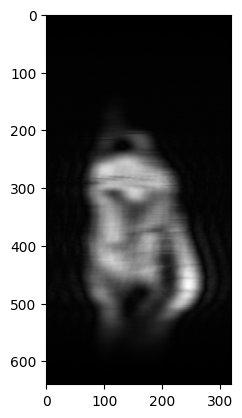

In [5]:
data = np.load("/home/biswamitra/health/knee_data/EDA/just_checking_padding_cropping.npy")
data_tensor = T.to_tensor(data)
data_ifft = fastmri.ifft2c(data_tensor)
data_rss = fastmri.rss(fastmri.complex_abs(data_ifft),dim=0)
plt.imshow(data_rss, cmap='gray')
plt.show()

### Testing section for the dataloader sanity



### Checking the flag's individual working.

In [3]:

ip_req_nos=5
op_req_nos=4

# Create all binary combination for input and output requests
input_combinations = list(itertools.product([0, 1], repeat=ip_req_nos))
output_combinations = list(itertools.product([0, 1], repeat=op_req_nos))

flag=0

# Loop through each combination
for input_req in input_combinations:
    print(f"Testing input_req={input_req}")
    for output_req in output_combinations:
        print(f"output_req={output_req}")
        dataset_check = Custom_FMRI_DataLoader_nil(
            data_paths,
            mask_func=EquiSpacedMaskFunc(center_fractions=[0.1], accelerations=[25]),
            input_req=list(input_req),
            output_req=list(output_req)
        )
        train_loader_check = DataLoader(dataset_check, batch_size=4, shuffle=True, num_workers=0)
        batch_1 = next(iter(train_loader_check)) 
        ll=batch_1.keys()
        if(len(ll) != sum(input_req)+sum(output_req)):
            flag=1
            break
    print("\n\n")

if (flag==1):
    print("Failed in sanity check.")
else:
    print("Good to Go !!!")
            

Testing input_req=(0, 0, 0, 0, 0)
output_req=(0, 0, 0, 0)


NameError: name 'data_paths' is not defined

In [3]:
folder_path= "/home/mahesh/health_ai_ons/Biswa_nil/data/" # /home/mahesh/health_ai_ons/data_ons/filtered_data/"
coil_count=4
height=640
width=320
tail="1"
ext=".npy"
file_name=f"coil_{coil_count}_{height}_{width}/"

def extract_file_paths(temp_path):
    data_paths = glob.glob(temp_path + "/*.npy")
    print(len(data_paths))
    return data_paths
data_paths=extract_file_paths(folder_path+file_name)
print(data_paths)

1990
['/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/3.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/1.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/2.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/4.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/5.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/6.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/7.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/8.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/9.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/10.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/11.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/12.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/13.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/14.npy', '/home/mahesh/health_ai_ons/Biswa_nil/data/coil_4_640_320/15.npy'

In [11]:
dataset_check = Custom_FMRI_DataLoader_nil(
            data_paths,
            mask_func=EquiSpacedMaskFunc(center_fractions=[0.04], accelerations=[3]),
            input_req=list(input_req),
            output_req=list(output_req)
        )
train_loader_check = DataLoader(dataset_check, batch_size=4, shuffle=False, num_workers=0)

In [13]:
# Setting the variables
epochs=10

batch_1 = next(iter(train_loader_check))
ll=batch_1.keys()
print (ll)
batchidx = 0
for l in ll:
    temp=batch_1[l]
    print(f"shape of {l}: {temp.shape}, type of {l}: {temp.dtype}\n")

dict_keys(['full_k_space', 'full_i_space', 'full_rss_combined', 'full_rss_fft', 'masked_k_space', 'masked_i_space', 'masked_rss_combined', 'masked_rss_combined_fft', 'mask'])
shape of full_k_space: torch.Size([4, 4, 640, 320]), type of full_k_space: torch.complex64

shape of full_i_space: torch.Size([4, 4, 640, 320]), type of full_i_space: torch.complex64

shape of full_rss_combined: torch.Size([4, 640, 320]), type of full_rss_combined: torch.float32

shape of full_rss_fft: torch.Size([4, 640, 320]), type of full_rss_fft: torch.complex64

shape of masked_k_space: torch.Size([4, 4, 640, 320]), type of masked_k_space: torch.complex64

shape of masked_i_space: torch.Size([4, 4, 640, 320]), type of masked_i_space: torch.complex64

shape of masked_rss_combined: torch.Size([4, 640, 320]), type of masked_rss_combined: torch.float32

shape of masked_rss_combined_fft: torch.Size([4, 640, 320]), type of masked_rss_combined_fft: torch.complex64

shape of mask: torch.Size([4, 4, 640, 320]), type o

In [14]:
import fastmri.data.transforms as T

def add_dim(Idata_slice):
    # Convert to torch.Tensor if needed
    if isinstance(Idata_slice, np.ndarray):
        data = torch.tensor(Idata_slice, dtype=torch.float32)
    else:
        data = Idata_slice.float()
    
    if data.ndim != 2:
        raise ValueError(f"Expected 2D input [H, W], got shape {data.shape}")

    data=data.unsqueeze(0)
    # Add imaginary channel = 0
    zeros = torch.zeros_like(data)
    data_complex = torch.stack(( zeros, data), dim=-1)  # [H, W, 2]
    img_complex = torch.view_as_complex(data_complex)
    print(img_complex.shape)
    return img_complex

/tmp/ipykernel_1999812/1098206920.py:8: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  data = Idata_slice.float()
/tmp/ipykernel_1999812/957924994.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  show_coils(np.log(np.abs(f_rss_fft) + 1e-9), [0], cmap='gray')
/tmp/ipykernel_1999812/957924994.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  show_coils(np.log(np.abs(m_rss_fft) + 1e-9), [0], cmap='gray')


torch.Size([1, 640, 320])
torch.Size([1, 640, 320])


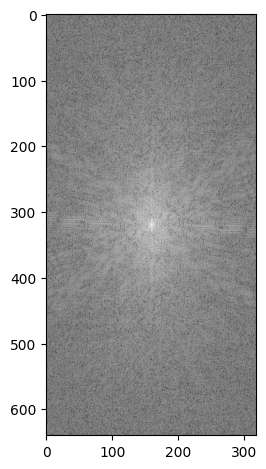

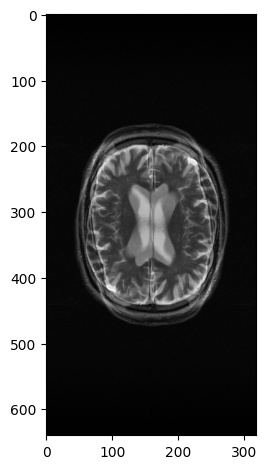

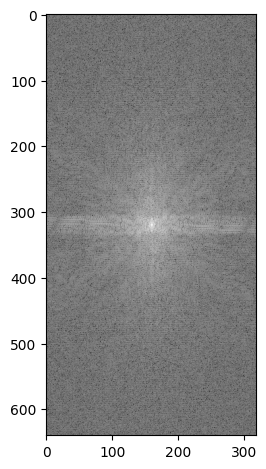

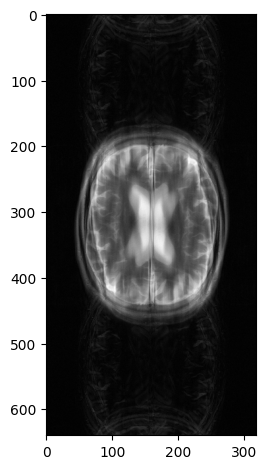

In [15]:


## RSS Combined FFT
# Full Rss Combined FFT
f_rss_fft_1= batch_1['full_rss_fft'][batchidx]
f_rss_fft=add_dim(f_rss_fft_1)

show_coils(np.log(np.abs(f_rss_fft) + 1e-9), [0], cmap='gray')
show_coils(np.abs(np.fft.ifft2(f_rss_fft)),[0])


#Masked RSS Combined FFT
m_rss_fft_1= batch_1['masked_rss_combined_fft'][batchidx]
m_rss_fft=add_dim(m_rss_fft_1)

show_coils(np.log(np.abs(m_rss_fft) + 1e-9), [0], cmap='gray')
show_coils(np.abs(np.fft.ifft2(m_rss_fft)),[0])


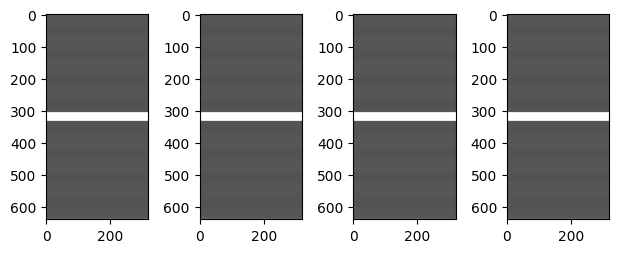

In [16]:
#Printing the mask out(K Space)
mask=batch_1["mask"][batchidx] 
show_multicoil_K_I(mask,K=True,show_image=False,  show_RSS = False)


torch.Size([4, 640, 320])


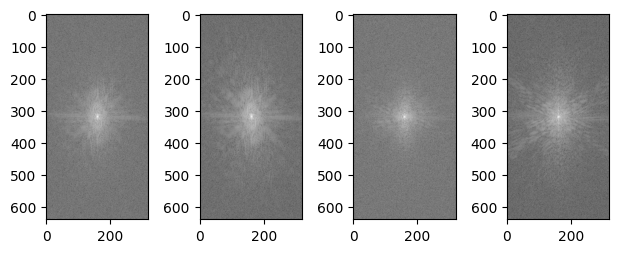

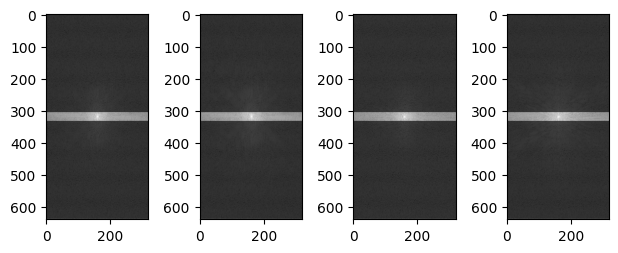

In [17]:
# Getting the data in K Space
#K Space
kspace = batch_1['full_k_space'][batchidx]
print(kspace.shape)
show_multicoil_K_I(kspace, show_image=False, show_RSS = False)


#Masked K Space
masked_kspace = batch_1['masked_k_space'][batchidx]  
show_multicoil_K_I(masked_kspace, show_image=False, show_RSS = True)


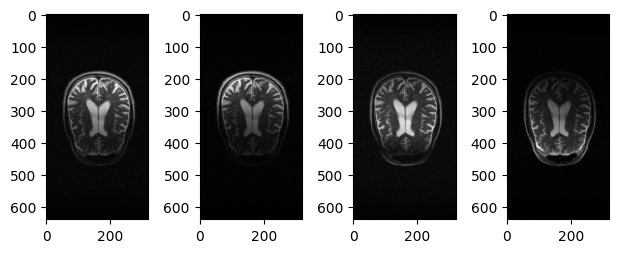

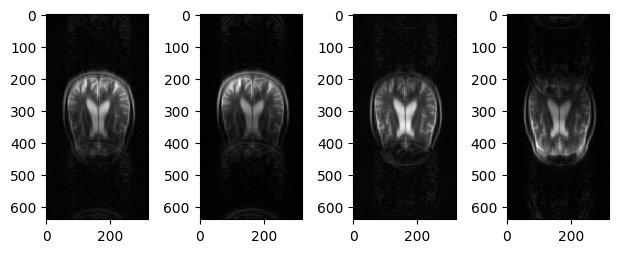

In [18]:
# Image Space
# I Space
ispace = batch_1['full_i_space'][batchidx]
show_multicoil_K_I(ispace, I=True,show_K=False, show_RSS = False)

# Masked I Space
masked_i_space = batch_1['masked_i_space'][batchidx] 
show_multicoil_K_I(masked_i_space, I=True, show_K=False,show_RSS = False)


torch.Size([1, 640, 320])
torch.Size([1, 640, 320])


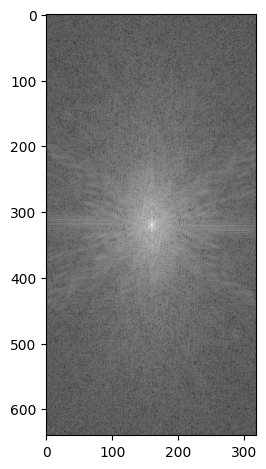

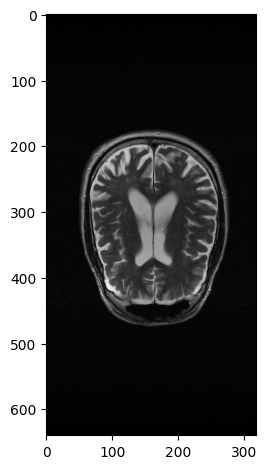

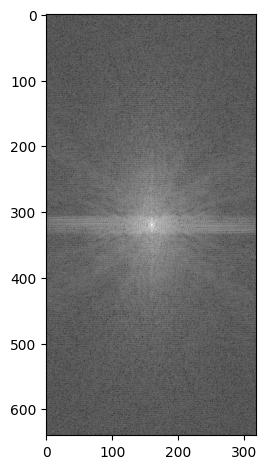

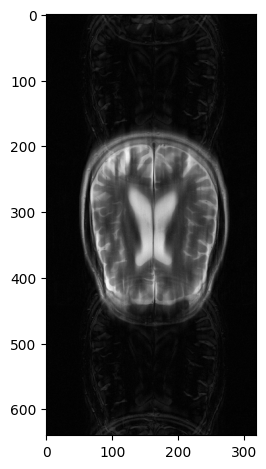

In [42]:
##['full_k_space', 'full_i_space', 'full_rss_combined', 'full_rss_fft', 'masked_k_space', 'masked_i_space', 'masked_rss_combined', 'masked_rss_combined_fft', 'mask']
## RSS Combined
# Full RSS
# Full RSS Combined
full_rss1 = batch_1['full_rss_combined'][batchidx]
full_rss=add_dim(full_rss1)
show_multicoil_K_I(full_rss.numpy(), I=True,show_RSS = False)


# Masked RSS
masked_rss1 = batch_1['masked_rss_combined'][batchidx]
masked_rss=add_dim(masked_rss1)
show_multicoil_K_I(masked_rss.numpy(), I=True,show_RSS = False)



#### For K-space Method

shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of input: torch.Size([4, 4, 640, 320]), type of target: torch.complex64


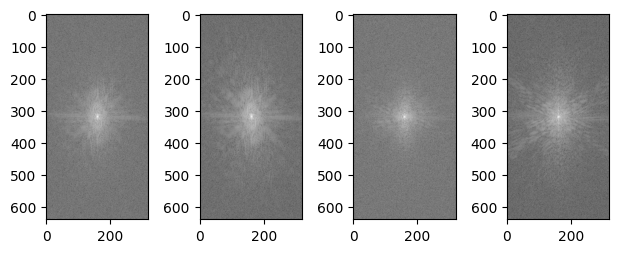

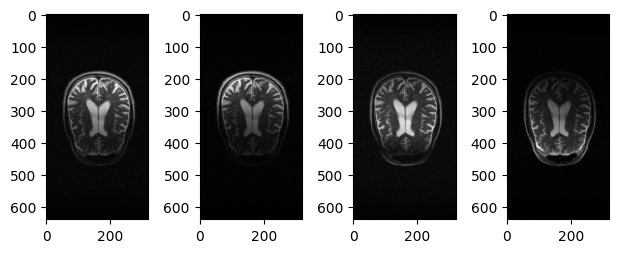

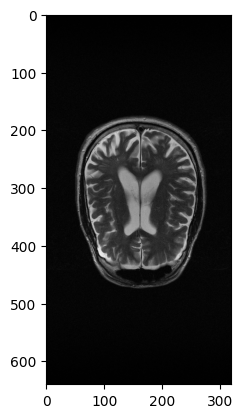

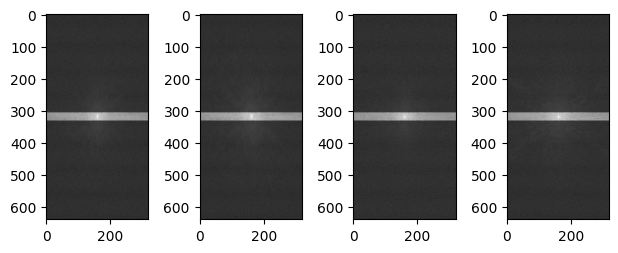

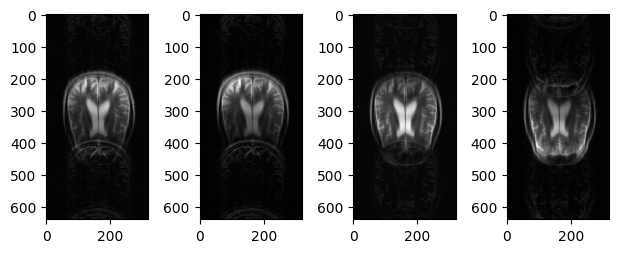

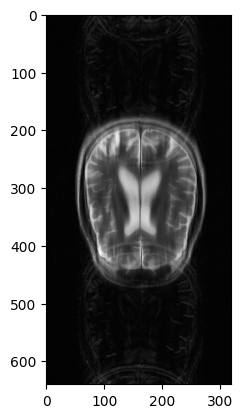

In [19]:
#### Subsampling K-space
batch_1 = next(iter(train_loader_check))
kspace = batch_1['full_k_space']
masked_kspace = batch_1['masked_k_space']
print(f"shape of target: {kspace.shape}, type of target: {kspace.dtype}")
print(f"shape of input: {masked_kspace.shape}, type of target: {masked_kspace.dtype}")
# Using Data loader
batchidx = 0
loader_kspace = kspace[batchidx,:,:,:]
loader_masked = masked_kspace[batchidx,:,:,:] 
show_multicoil_K_I(loader_kspace)
show_multicoil_K_I(loader_masked)

In [20]:
batch_size = 4
num_epochs = 10
learning_rate = 1e-4
batchidx = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"The process is going to run with {learning_rate} learning rate, in {device}, with batch size {batch_size} for {num_epochs} no. of epochs.")

The process is going to run with 0.0001 learning rate, in cuda, with batch size 4 for 10 no. of epochs.


In [21]:
brk="*********************************************************"

tt=time.time()
for i in range(epochs):
    start=time.time()
    for batch in train_loader_check:
        kspace = batch['full_k_space']
        print(f"shape of target: {kspace.shape}, type of target: {kspace.dtype}")
        # Using Data loader
        loader_kspace = kspace[batchidx,:,:,:]
        loader_masked = masked_kspace[batchidx,:,:,:]
    end=time.time()
    t=end-start
    print(f"The itteration {i+1}/ {epochs} took {t} seconds.")
    print(brk)
tt2=time.time()
total_time=tt2-tt

print(f"Total {epochs} rounds, had taken {total_time} seconds for the execution.")


shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type of target: torch.complex64
shape of target: torch.Size([4, 4, 640, 320]), type 

## I to K to I loss


In [23]:
import torch
import torch.nn.functional as F

def process_batches(data_loader, num_batches=10):
    
    for i, batch in enumerate(data_loader):
        if i >= num_batches:
            break

        ispace_complex = batch['ispace'][0]  
        
        # FFT and then IFFT reconstruction
        fft = torch.fft.fftn(ispace_complex, dim=(-2, -1))
        recon = torch.fft.ifftn(fft, dim=(-2, -1))

        # Compute error in the complex domain
        error = recon - ispace_complex  # Both should be complex tensors

        # Compute RMSE (complex-valued): real and imaginary parts both included
        rmse = torch.sqrt(torch.mean(error.real**2 + error.imag**2))

        print(f"Batch {i+1}/{num_batches} - Complex RMSE: {rmse.item()}")

        # print(f"Batch {i+1}/{num_batches} - MSE Loss: {loss.item(): }")

# Example usage:
process_batches(train_loader_check, num_batches=5)


KeyError: 'ispace'

## Native Loader of FastMRI